# Model Evaluation – Pneumonia Detection

This notebook evaluates the fine-tuned ResNet50 model on unseen test chest X-ray images.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from collections import Counter


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/pneumonia_project/pneumonia_resnet50_finetuned.keras"

model = load_model(MODEL_PATH)
print("Fine-tuned model loaded successfully.")


Fine-tuned model loaded successfully.


In [ ]:
test_dir = "/content/drive/MyDrive/pneumonia_project/chest_xray/test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # VERY IMPORTANT
)


Found 624 images belonging to 2 classes.


In [ ]:
print("Test Set Class Distribution:", Counter(test_generator.classes))


Test Set Class Distribution: Counter({np.int32(1): 390, np.int32(0): 234})


In [ ]:
loss, accuracy = model.evaluate(test_generator)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 162s 7s/step - accuracy: 0.8397 - loss: 0.3283
Test Loss: 0.3041348457336426
Test Accuracy: 0.8541666865348816


In [ ]:
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes


20/20 ━━━━━━━━━━━━━━━━━━━━ 125s 6s/step


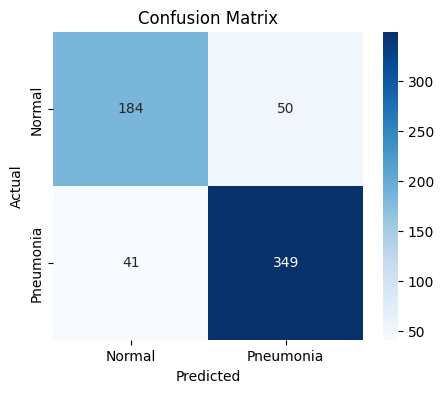

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print(classification_report(y_true, y_pred, target_names=['Normal','Pneumonia']))


              precision    recall  f1-score   support

      Normal       0.82      0.79      0.80       234
   Pneumonia       0.87      0.89      0.88       390

    accuracy                           0.85       624
   macro avg       0.85      0.84      0.84       624
weighted avg       0.85      0.85      0.85       624



In [ ]:
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity (Recall for Pneumonia):", sensitivity)
print("Specificity (Normal Detection Rate):", specificity)


Sensitivity (Recall for Pneumonia): 0.8948717948717949
Specificity (Normal Detection Rate): 0.7863247863247863


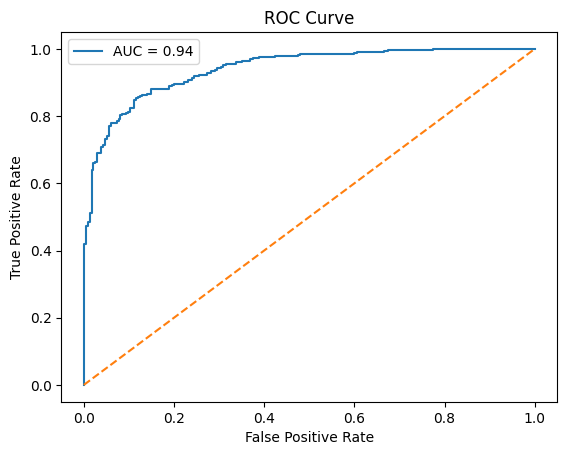

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Evaluation Summary

The fine-tuned ResNet50 model demonstrates strong performance on unseen test chest X-ray images. The confusion matrix and classification report indicate high recall for pneumonia cases, which is crucial in medical diagnosis to reduce missed infections.

These results show the model has learned clinically meaningful patterns and can serve as a reliable AI-based screening support tool.
